# Retail Sales Data Analysis

In [116]:
import pandas as pd

In [117]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Collection and Loading

In [118]:
df = pd.read_csv("online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Exploratory Data Analysis

In [119]:
df.columns
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [121]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [122]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


## Data Cleaning

In [123]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [124]:
df = df.dropna()

In [125]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [126]:
df = df.drop_duplicates()

In [127]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

## Data Preparation

In [128]:
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

In [129]:
df['Month'] = df['InvoiceDate'].dt.month

df['Year'] = df['InvoiceDate'].dt.year



In [130]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalSales,Month,Year
count,401604.000000,401604,401604.000000,401604.000000,401604.000000,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567,3.474064,15281.160818,20.613638,7.595407,2010.934378
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000,1.000000,2010.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000,4.250000,5.000000,2011.000000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000,11.700000,8.000000,2011.000000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000,19.800000,11.000000,2011.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000,12.000000,2011.000000
std,250.283037,NaN,69.764035,1714.006089,430.352218,3.417451,0.247620


## Data Analysis

In [131]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print(top_products)


Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53119
JUMBO BAG RED RETROSPOT               44963
ASSORTED COLOUR BIRD ORNAMENT         35215
WHITE HANGING HEART T-LIGHT HOLDER    34128
PACK OF 72 RETROSPOT CAKE CASES       33386
POPCORN HOLDER                        30492
RABBIT NIGHT LIGHT                    27045
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25305
PACK OF 60 PINK PAISLEY CAKE CASES    24129
Name: Quantity, dtype: int64


In [132]:
top_countries = df.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(10)

print(top_countries)


Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: TotalSales, dtype: float64


In [133]:
monthly_sales = df.groupby('Month')['TotalSales'].sum()

print(monthly_sales)

Month
1      473731.900
2      435534.070
3      578576.210
4      425222.671
5      647011.670
6      606862.520
7      573112.321
8      615078.090
9      929356.232
10     973306.380
11    1126815.070
12     893912.290
Name: TotalSales, dtype: float64


## Time Series Analysis

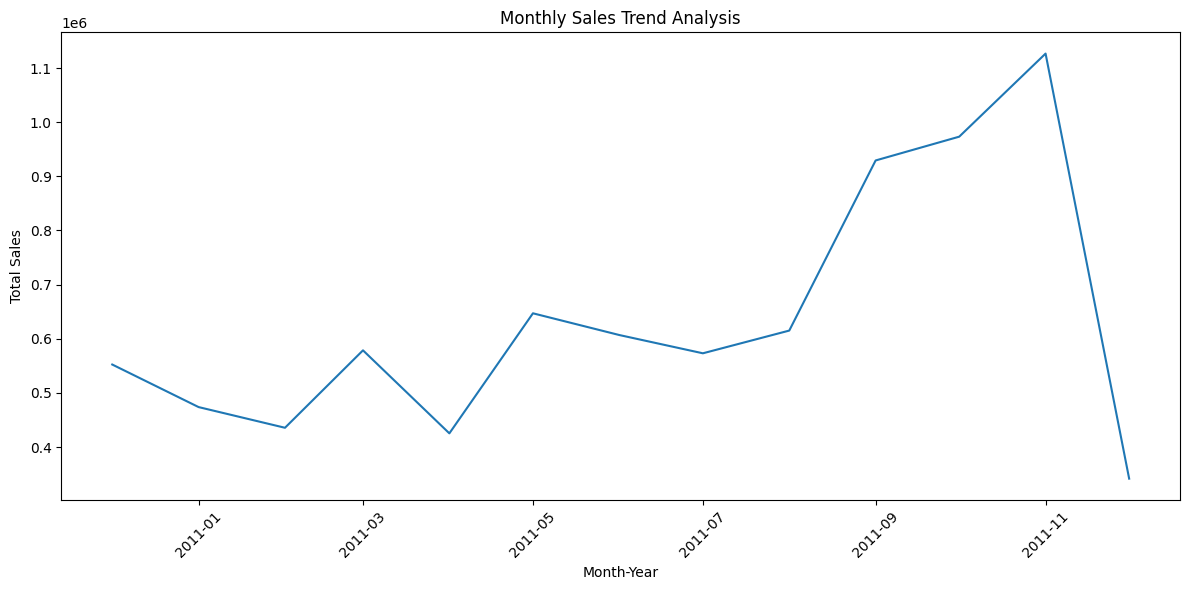

In [134]:
# Create Month-Year column

df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

# Calculate monthly sales

monthly_sales_trend = df.groupby('MonthYear')['TotalSales'].sum()

# Convert PeriodIndex to Timestamp

monthly_sales_trend.index = monthly_sales_trend.index.to_timestamp()

# Plot Time Series Graph

plt.figure(figsize=(12,6))

plt.plot(monthly_sales_trend.index,
         monthly_sales_trend.values)

plt.title("Monthly Sales Trend Analysis")

plt.xlabel("Month-Year")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Customer Analysis

In [135]:
# Top 5 customers by total sales

top_customers = df.groupby('CustomerID')['TotalSales'].sum().sort_values(ascending=False).head(5)

print(top_customers)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
Name: TotalSales, dtype: float64


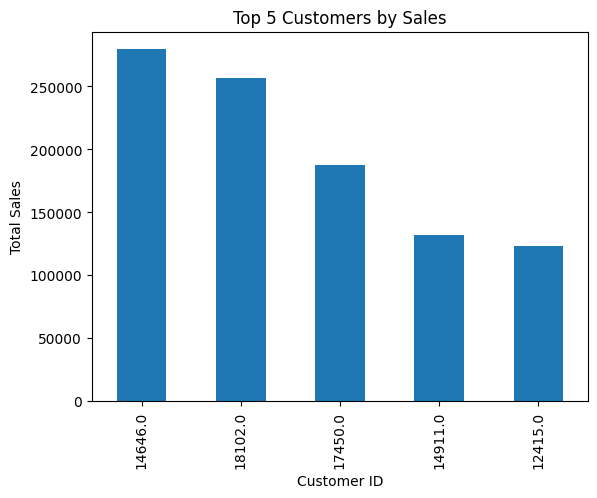

In [136]:
top_customers.plot(kind='bar')

plt.title("Top 5 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")

plt.show()

## Data Visualization

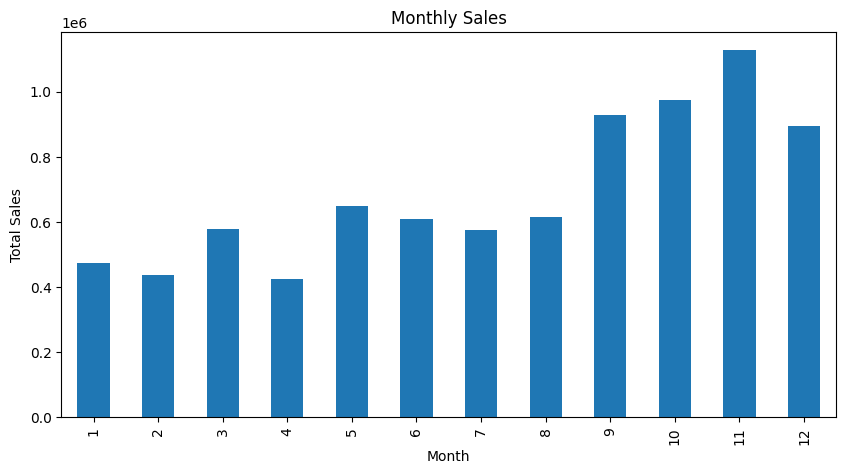

In [137]:
plt.figure(figsize=(10,5))

monthly_sales.plot(kind='bar')

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.show()

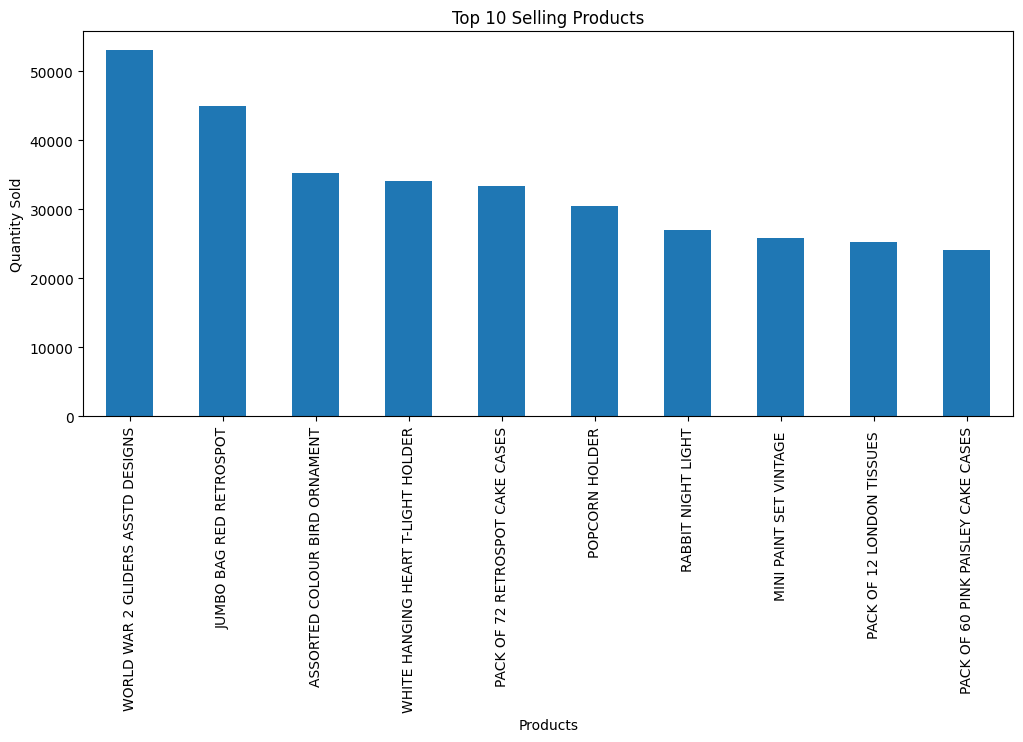

In [138]:
plt.figure(figsize=(12,5))

top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")

plt.xlabel("Products")

plt.ylabel("Quantity Sold")

plt.show()

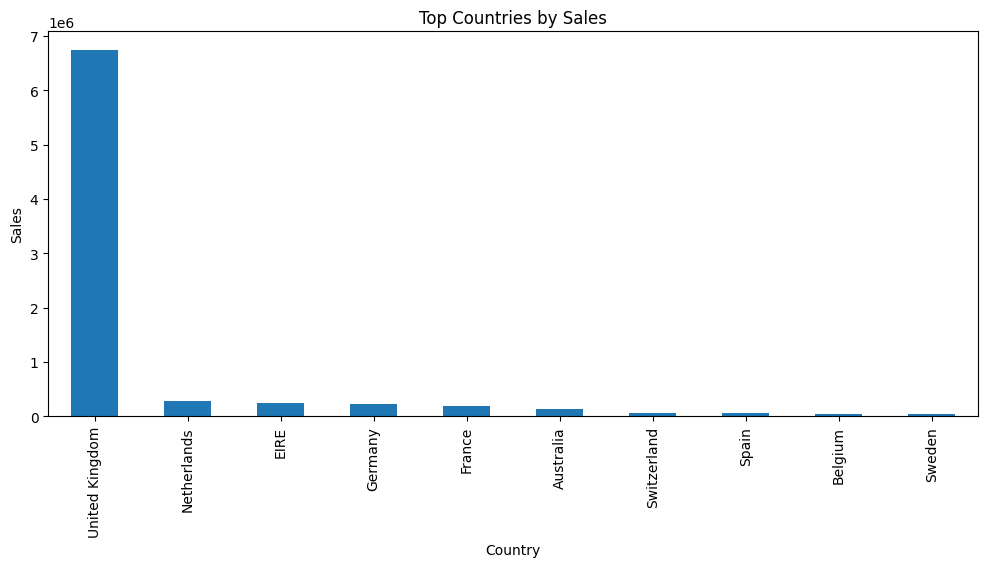

In [139]:
plt.figure(figsize=(12,5))

top_countries.plot(kind='bar')

plt.title("Top Countries by Sales")

plt.xlabel("Country")

plt.ylabel("Sales")

plt.show()


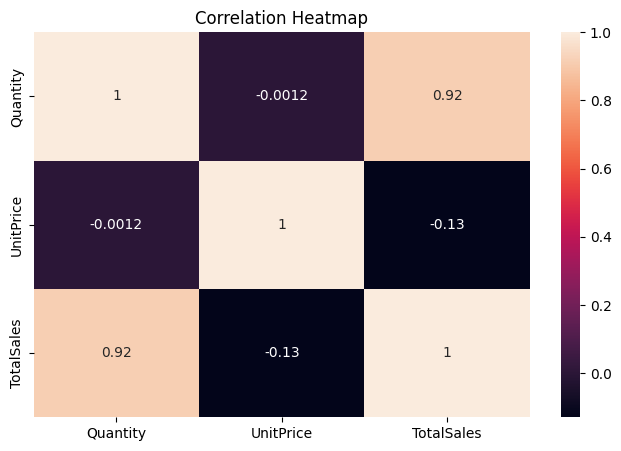

In [140]:
plt.figure(figsize=(8,5))

sns.heatmap(df[['Quantity','UnitPrice','TotalSales']].corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()


## RFM Analysis

In [141]:
# Recency

recency = df.groupby('CustomerID')['InvoiceDate'].max()

# Frequency

frequency = df.groupby('CustomerID')['InvoiceNo'].count()

# Monetary

monetary = df.groupby('CustomerID')['TotalSales'].sum()

# Combine

rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2011-01-18 10:17:00,2,0.00
12347.0,2011-12-07 15:52:00,182,4310.00
12348.0,2011-09-25 13:13:00,31,1797.24
12349.0,2011-11-21 09:51:00,73,1757.55
12350.0,2011-02-02 16:01:00,17,334.40


## Customer Segmentation

In [142]:
def segment_customer(row):
    if row['Monetary'] > 5000:
        return 'High Value'
    elif row['Monetary'] > 1000:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Segment
CustomerID,,,,
12346.0,2011-01-18 10:17:00,2,0.00,Low Value
12347.0,2011-12-07 15:52:00,182,4310.00,Medium Value
12348.0,2011-09-25 13:13:00,31,1797.24,Medium Value
12349.0,2011-11-21 09:51:00,73,1757.55,Medium Value
12350.0,2011-02-02 16:01:00,17,334.40,Low Value


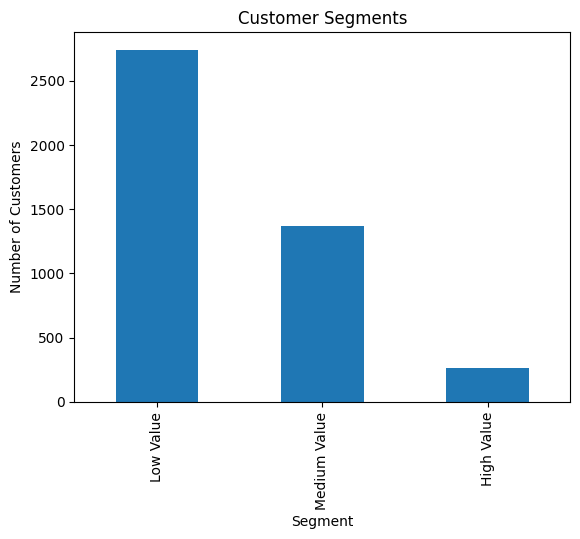

In [143]:
rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

## Analyzing Top Customers

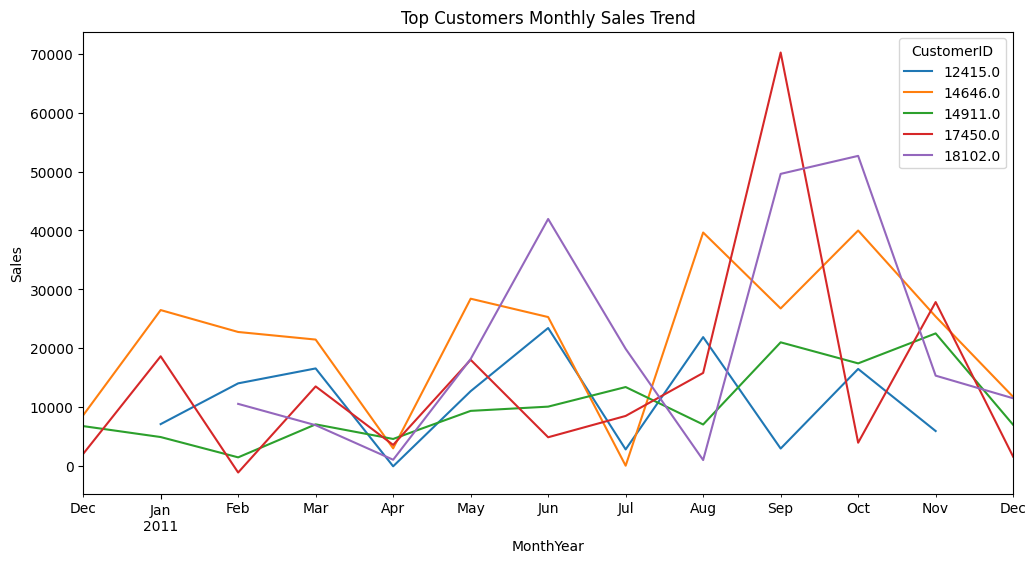

In [144]:
# Month-Year

df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

# Top 5 customers

top_5_customers = df.groupby('CustomerID')['TotalSales'].sum().sort_values(ascending=False).head(5).index

# Filter

top_customers_df = df[df['CustomerID'].isin(top_5_customers)]

# Monthly sales

top_customer_sales = top_customers_df.groupby(
    ['CustomerID','MonthYear']
)['TotalSales'].sum().unstack(0)

top_customer_sales.plot(figsize=(12,6))

plt.title("Top Customers Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

## Conclusion

This project analyzed retail transaction data to identify sales trends and customer behavior. After cleaning the dataset, monthly sales patterns and top-selling products were studied. Customer segmentation helped identify high-value customers. The analysis can help businesses improve marketing and sales strategies.

In [145]:

df.to_csv("cleaned_retail_data.csv", index=False)

print("Project Completed Successfully")

Project Completed Successfully
